##### Run in the dedicated `kea` environment created from `kea-env.yml`

#### Setup

In [1]:
import gzip, os, re, sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from modpa_network_utilities import parse_network, build_graph, run_leiden, build_clusters_df, add_protein_annotations, count_edges, count_nodes

In [3]:
FASTA_PATH = "../1-quant-pipeline-latest/Human_2026_01_canonical.fasta.gz"

proteins = []
with gzip.open(FASTA_PATH, "rt") as file:
    for record in SeqIO.parse(file, "fasta"):
        _, uniacc, entry = record.id.split("|", 2)
        gene = re.search(r"(?:^| )GN=(\w+)", record.description)
        proteins.append([
            uniacc, str(record.seq), entry, gene.group(1) if gene else np.nan,
            ">" + record.description
        ])
proteins = pd.DataFrame(proteins, columns=["UniAcc", "Seq", "Entry", "Gene", "Header"])

In [4]:
true_model_edges   = "./20260819-1231-s140206771-funny_keller/20260819-1335-funny_keller-signed-distances.csv.gz"
true_filtered_path = os.path.join(os.path.dirname(true_model_edges), "True-data-filtered-distances.csv")
true_clusters_path = os.path.join(os.path.dirname(true_model_edges), "True-data-Leiden-clusters.csv")

shuffled_model_edges   = "./20260819-1321-s1168567929-keen_raman/20260819-1351-keen_raman-signed-distances.csv.gz"
shuffled_filtered_path = os.path.join(os.path.dirname(shuffled_model_edges), "Shuffled-data-filtered-distances.csv")
shuffled_clusters_path = os.path.join(os.path.dirname(shuffled_model_edges), "Shuffled-data-Leiden-clusters.csv")

df shape = (11243505, 22)


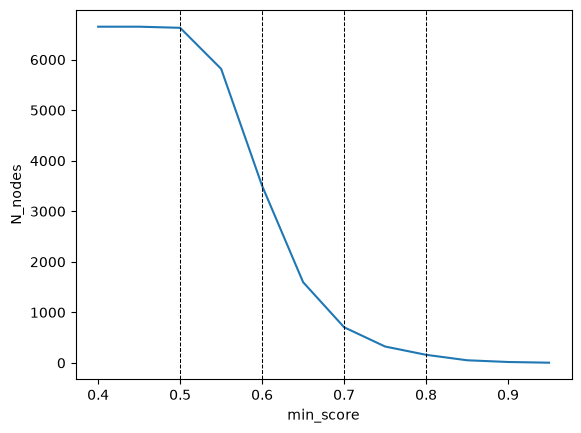

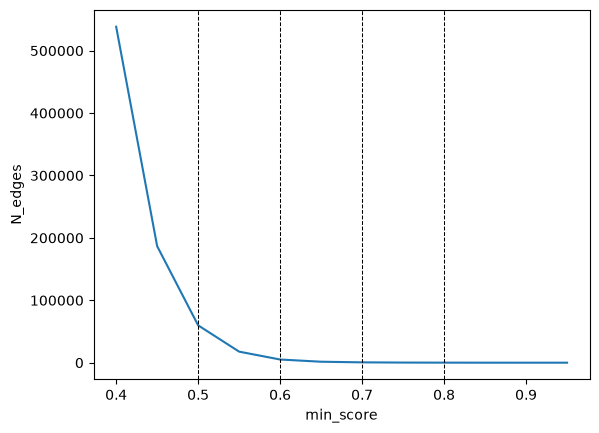

In [5]:
data_tmp = parse_network(true_model_edges, min_score=0).collect(engine="streaming")
print("df shape =", data_tmp.shape)

tmp = []
for n in np.arange(0.4, 1, .05):
    tmp.append((np.round(n,2),
                count_nodes(data_tmp.filter(pl.col("Score")>=n))))
tmp = pd.DataFrame(tmp, columns=['min_score','N_nodes'])
sns.lineplot(data=tmp, x='min_score', y='N_nodes')
plt.axvline(0.7, color='k', ls='--', lw=.75)
plt.axvline(0.8, color='k', ls='--', lw=.75)
plt.axvline(0.6, color='k', ls='--', lw=.75)
plt.axvline(0.5, color='k', ls='--', lw=.75)
plt.show()

tmp = []
for n in np.arange(0.4, 1, .05):
    tmp.append((np.round(n,2),
                count_edges(data_tmp.filter(pl.col("Score")>=n))))
tmp = pd.DataFrame(tmp, columns=['min_score','N_edges'])
sns.lineplot(data=tmp, x='min_score', y='N_edges')
plt.axvline(0.7, color='k', ls='--', lw=.75)
plt.axvline(0.8, color='k', ls='--', lw=.75)
plt.axvline(0.6, color='k', ls='--', lw=.75)
plt.axvline(0.5, color='k', ls='--', lw=.75)
plt.show()

----------

#### Clustering

In [6]:
# default params
LEIDEN_SEED  = 42
LEIDEN_RES   = 2
LEIDEN_NITER = 2
MIN_SCORE    = 0.6
ADJ_WINDOW   = 5

In [7]:
true_data = parse_network(
    true_model_edges, min_score=MIN_SCORE, adjacency_window=ADJ_WINDOW
).collect(engine="streaming")
true_data.write_csv(true_filtered_path)
print("# Nodes =", count_nodes(true_data), "; # Edges =", count_edges(true_data))
print(true_data)

true_network = build_graph(true_data)
true_membership = run_leiden(
    true_network, seed=LEIDEN_SEED, resolution=LEIDEN_RES, n_iterations=LEIDEN_NITER
)
true_clusters_df = build_clusters_df(true_membership)
true_clusters_df = add_protein_annotations(true_clusters_df, proteins)
true_clusters_df.to_csv(true_clusters_path, index=False)

print("No. clusters =", true_clusters_df["LeidenCluster"].nunique(), "\n")
print("Top 10 largest clusters:")
print(true_clusters_df["LeidenCluster"].value_counts().head(10))

# Nodes = 3503 ; # Edges = 5099
shape: (5_099, 22)
┌─────────────────┬────────────────┬──────────┬──────┬───┬──────────┬────────────────┬────────────────┬────────────────┐
│ nodeA           ┆ nodeB          ┆ Score    ┆ pval ┆ … ┆ same_mod ┆ shared_peptide ┆ potential_arte ┆ pair_key       │
│ ---             ┆ ---            ┆ ---      ┆ ---  ┆   ┆ ---      ┆ ---            ┆ fact           ┆ ---            │
│ str             ┆ str            ┆ f64      ┆ f64  ┆   ┆ bool     ┆ bool           ┆ ---            ┆ str            │
│                 ┆                ┆          ┆      ┆   ┆          ┆                ┆ bool           ┆                │
╞═════════════════╪════════════════╪══════════╪══════╪═══╪══════════╪════════════════╪════════════════╪════════════════╡
│ A0FGR8|738|S|21 ┆ Q6WCQ1|226|S|2 ┆ 0.608783 ┆ 0.0  ┆ … ┆ true     ┆ false          ┆ false          ┆ A0FGR8|738|S|2 │
│                 ┆ 1              ┆          ┆      ┆   ┆          ┆                ┆                

In [8]:
shuffled_data = parse_network(
    shuffled_model_edges, min_score=MIN_SCORE, adjacency_window=ADJ_WINDOW
).collect(engine="streaming")
shuffled_data.write_csv(shuffled_filtered_path)
print("# Nodes =", count_nodes(shuffled_data), "; # Edges =", count_edges(shuffled_data))
print(shuffled_data)

shuffled_network = build_graph(shuffled_data)
shuffled_membership = run_leiden(
    shuffled_network, seed=LEIDEN_SEED, resolution=LEIDEN_RES, n_iterations=LEIDEN_NITER
)
shuffled_clusters_df = build_clusters_df(shuffled_membership)
shuffled_clusters_df = add_protein_annotations(shuffled_clusters_df, proteins)
shuffled_clusters_df.to_csv(shuffled_clusters_path, index=False)

print("No. clusters =", shuffled_clusters_df["LeidenCluster"].nunique(), "\n")
print("Top 10 largest clusters:")
print(shuffled_clusters_df["LeidenCluster"].value_counts().head(10))

# Nodes = 42 ; # Edges = 21
shape: (21, 22)
┌─────────────────┬────────────────┬──────────┬──────┬───┬──────────┬────────────────┬────────────────┬────────────────┐
│ nodeA           ┆ nodeB          ┆ Score    ┆ pval ┆ … ┆ same_mod ┆ shared_peptide ┆ potential_arte ┆ pair_key       │
│ ---             ┆ ---            ┆ ---      ┆ ---  ┆   ┆ ---      ┆ ---            ┆ fact           ┆ ---            │
│ str             ┆ str            ┆ f64      ┆ f64  ┆   ┆ bool     ┆ bool           ┆ ---            ┆ str            │
│                 ┆                ┆          ┆      ┆   ┆          ┆                ┆ bool           ┆                │
╞═════════════════╪════════════════╪══════════╪══════╪═══╪══════════╪════════════════╪════════════════╪════════════════╡
│ O94979|532|S|21 ┆ Q8WYJ6|320|S|2 ┆ 0.610016 ┆ 0.0  ┆ … ┆ true     ┆ false          ┆ false          ┆ O94979|532|S|2 │
│                 ┆ 1              ┆          ┆      ┆   ┆          ┆                ┆                ┆ 1__Q8

------

#### Genes per cluster

In [9]:
clusters_df = pd.read_csv(true_clusters_path)
# clusters_df

In [10]:
genes_per_cluster = []
for c,df in clusters_df.groupby("LeidenCluster").__iter__():
    genes_per_cluster.append([
        len(set(df.Gene)), 
        "Leiden"
    ])

for _ in range(10):
    labels = list(clusters_df.LeidenCluster)
    np.random.seed(_**3)
    np.random.shuffle(labels)
    clusters_df["ShuffledCluster"] = labels
    for c,df in clusters_df.groupby("ShuffledCluster").__iter__():
        genes_per_cluster.append([
            len(set(df.Gene)),
            f"random_{_}"
        ])
genes_per_cluster = pd.DataFrame(genes_per_cluster, columns=["n_genes","source"])

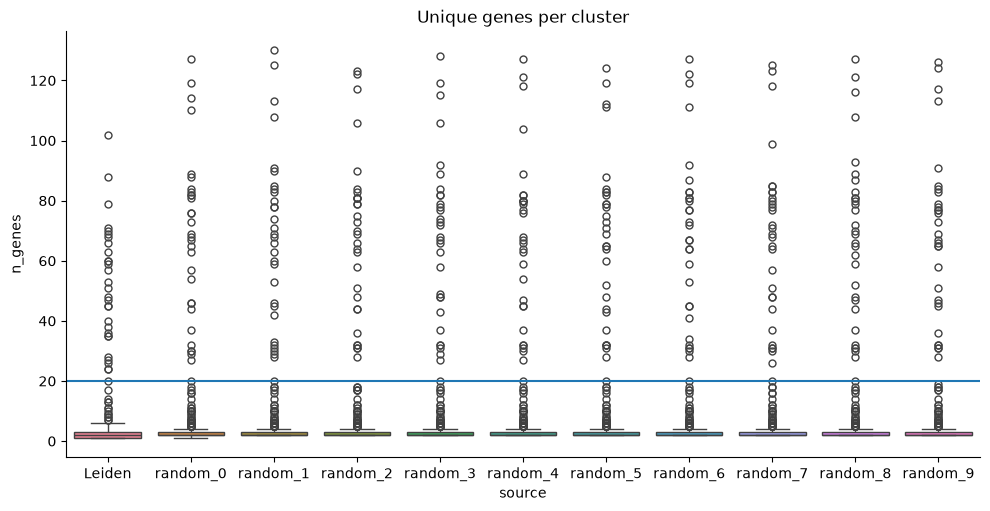

In [12]:
sns.catplot(data=genes_per_cluster, kind='box', y="n_genes", x="source", hue="source", aspect=2)
plt.axhline(20)
plt.title('Unique genes per cluster')
plt.savefig(
    os.path.join(os.path.dirname(shuffled_model_edges), "Clusters-size-distribution.svg")
)

In [13]:
genes_per_cluster.groupby("source").describe()

n_genes                                                
           count      mean        std  min  25%  50%  75%    max
source                                                          
Leiden     476.0  5.283613  13.041046  1.0  1.0  2.0  3.0  102.0
random_0   476.0  7.079832  17.432273  1.0  2.0  2.0  3.0  127.0
random_1   476.0  7.079832  17.477382  2.0  2.0  2.0  3.0  130.0
random_2   476.0  7.065126  17.336969  2.0  2.0  2.0  3.0  123.0
random_3   476.0  7.081933  17.416617  2.0  2.0  2.0  3.0  128.0
random_4   476.0  7.073529  17.352471  2.0  2.0  2.0  3.0  127.0
random_5   476.0  7.079832  17.324091  2.0  2.0  2.0  3.0  124.0
random_6   476.0  7.100840  17.554676  2.0  2.0  2.0  3.0  127.0
random_7   476.0  7.067227  17.324874  2.0  2.0  2.0  3.0  125.0
random_8   476.0  7.117647  17.567159  2.0  2.0  2.0  3.0  127.0
random_9   476.0  7.096639  17.480188  2.0  2.0  2.0  3.0  126.0

---------